# 스타일 전이 — 모델 대신 이미지를 최적화하기

**11장 11-2절 심화 학습 자료**의 예제 노트북이다. 설명은 [`README.md`](README.md)를 함께 읽자.

모델의 파라미터를 고정해 두고 **이미지의 픽셀을 직접 최적화**해, 독일 튀빙겐 거리
사진에 반 고흐 <별이 빛나는 밤>의 화풍을 입힌다.


## 0. 환경 준비

In [1]:

# 공통 라이브러리 로딩
#   저장소 전체를 clone하지 않았다면 code_reference/README.md를 먼저 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz

viz.configure(save_grayscale=False)
common.set_korean_plot_env()

SEED = 42
common.set_seed(SEED)
device = common.get_device()

CUDA를 사용합니다.


In [2]:

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from torchvision import transforms, models

# 결과 그림을 저장할 디렉터리
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

## 1. 그람 행렬

스타일은 "무엇이 어디에 있는가"가 아니라 "어떤 특징들이 함께 나타나는가"다.
그람 행렬은 채널끼리 내적해 **공간 정보를 지우고 채널 사이의 관계만 남긴다.**

In [3]:

def gram_matrix(feature):
    """(B, C, H, W) 특징 지도로 (B, C, C) 그람 행렬을 만든다."""
    B, C, H, W = feature.shape
    # 채널 단위의 1차원 벡터로 펼침: 이 순간 공간 구조가 사라진다
    f = feature.view(B, C, H * W)
    # 채널 벡터 사이의 내적 = 두 특징이 함께 나타나는 강도
    gram = torch.bmm(f, f.transpose(1, 2))          # (B, C, C)
    # 계층마다 채널 수와 공간 크기가 달라, 정규화하지 않으면 한 계층이 압도한다
    return gram / (C * H * W)


# 공간 정보가 실제로 사라지는지 확인한다: 픽셀을 뒤섞어도 그람 행렬은 그대로다
probe = torch.randn(1, 4, 8, 8)
shuffled = probe.view(1, 4, -1)[:, :, torch.randperm(64)].view(1, 4, 8, 8)
print('원본과 픽셀을 뒤섞은 특징 지도의 그람 행렬 최대 차이:',
      f'{(gram_matrix(probe) - gram_matrix(shuffled)).abs().max():.2e}')
print('반면 특징 지도 자체의 최대 차이:',
      f'{(probe - shuffled).abs().max():.4f}')

원본과 픽셀을 뒤섞은 특징 지도의 그람 행렬 최대 차이: 5.96e-08
반면 특징 지도 자체의 최대 차이: 4.0849


## 2. 이미지 준비

VGG-19는 ImageNet을 특정 평균·표준편차로 정규화해 학습했다. 모델을 재활용하려면
**입력 분포도 같게 맞춰야 한다.**

콘텐츠 이미지: (1, 3, 256, 256)
스타일 이미지: (1, 3, 256, 256)


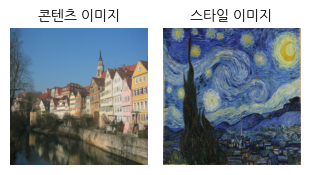

In [4]:

IMG_SIZE = 256

# ImageNet 정규화 상수(역변환에도 쓴다)
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)


def load_image(path, size=IMG_SIZE):
    img = Image.open(path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN.flatten().tolist(),
                             std=STD.flatten().tolist()),
    ])
    return transform(img).unsqueeze(0).to(device)


def denormalize(img_tensor):
    """정규화를 되돌려 0~1 범위의 표시용 텐서로 바꾼다."""
    img = img_tensor.detach().cpu()
    return (img * STD + MEAN).clamp(0, 1)


content_img = load_image('../../data/Tuebingen_Neckarfront.jpg')
style_img = load_image('../../data/starry_night.jpg')
print(f'콘텐츠 이미지: {tuple(content_img.shape)}')
print(f'스타일 이미지: {tuple(style_img.shape)}')

viz.plot_images([denormalize(content_img)[0], denormalize(style_img)[0]],
                ['콘텐츠 이미지', '스타일 이미지'], images_per_row=2,
                fig_title_size=10)

## 3. 특징 추출기

사전 학습된 VGG-19의 합성곱 블록만 쓴다. **`requires_grad = False`가 이 글의
핵심 한 줄이다.** 기울기는 VGG-19를 *거쳐* 흐르지만 그 끝은 모델 파라미터가
아니라 입력 이미지다.

In [5]:

class VGG19FeatureExtractor(nn.Module):
    def __init__(self, content_layer_idxs, style_layer_idxs):
        super().__init__()
        vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
        # 분류기는 쓰지 않고 합성곱 블록만 사용
        self.features = vgg.features
        self.content_layer_idxs = content_layer_idxs
        self.style_layer_idxs = style_layer_idxs
        # 이미지를 최적화할 때 VGG-19가 함께 갱신되지 않도록 고정
        for param in self.parameters():
            param.requires_grad = False

    def forward(self, x):
        content_features, style_features = {}, {}
        # 계층을 순서대로 통과시키며 지정한 위치의 특징 지도를 수집
        for idx, layer in enumerate(self.features):
            x = layer(x)
            if idx in self.content_layer_idxs:
                content_features[idx] = x
            if idx in self.style_layer_idxs:
                style_features[idx] = x
        return content_features, style_features


# 콘텐츠: 출력에 가까운 한 계층 / 스타일: 얕은 곳부터 깊은 곳까지 고루
content_layer_idxs = [21]
style_layer_idxs = [0, 5, 10, 19, 28]

feature_extractor = VGG19FeatureExtractor(
    content_layer_idxs, style_layer_idxs).to(device).eval()

# 합성곱 계층의 인덱스를 확인해 둔다(연습 문제 2에서 사용)
conv_idxs = [i for i, l in enumerate(feature_extractor.features)
             if isinstance(l, nn.Conv2d)]
print(f'VGG-19 합성곱 계층 {len(conv_idxs)}개의 인덱스: {conv_idxs}')
print(f'콘텐츠 추출 계층 {content_layer_idxs} '
      f'(= {conv_idxs.index(21) + 1}번째 합성곱 계층)')
print(f'스타일 추출 계층 {style_layer_idxs}')

VGG-19 합성곱 계층 16개의 인덱스: [0, 2, 5, 7, 10, 12, 14, 16, 19, 21, 23, 25, 28, 30, 32, 34]
콘텐츠 추출 계층 [21] (= 10번째 합성곱 계층)
스타일 추출 계층 [0, 5, 10, 19, 28]


## 4. 손실 함수

콘텐츠 손실은 특징 지도를 그대로 비교하고, 스타일 손실은 그람 행렬을 비교한다.
두 항의 눈금이 크게 달라 가중치로 맞춘다.

In [6]:

mse_loss = nn.MSELoss()


def criterion(generated_content_features, generated_style_features,
              content_image_features, style_image_features,
              content_weight=1.0, style_weight=1e5):
    # 콘텐츠 손실: 지정한 계층의 특징 지도를 그대로 비교
    content_loss = sum(
        mse_loss(generated_content_features[idx], content_image_features[idx])
        for idx in content_layer_idxs
    )
    # 스타일 손실: 지정한 계층들의 그람 행렬을 비교
    style_loss = sum(
        mse_loss(gram_matrix(generated_style_features[idx]),
                 gram_matrix(style_image_features[idx]))
        for idx in style_layer_idxs
    )
    total_loss = content_weight * content_loss + style_weight * style_loss
    return total_loss, content_loss, style_loss


# 두 손실항의 눈금 차이를 눈으로 확인한다
with torch.no_grad():
    c_feat, _ = feature_extractor(content_img)
    _, s_feat = feature_extractor(style_img)
    blank = torch.zeros_like(content_img)
    g_c, g_s = feature_extractor(blank)
    _, c_loss, s_loss = criterion(g_c, g_s, c_feat, s_feat)
print(f'빈 이미지 기준 콘텐츠 손실 {c_loss.item():.4f}, '
      f'스타일 손실 {s_loss.item():.8f}')
print(f'비율: 약 {c_loss.item() / s_loss.item():.0f}배 '
      '-> style_weight를 크게 잡아야 균형이 맞는다')

빈 이미지 기준 콘텐츠 손실 11.0248, 스타일 손실 0.00027687
비율: 약 39819배 -> style_weight를 크게 잡아야 균형이 맞는다


## 5. 학습 루프

일반적인 학습 루프와 모양이 같다. 바뀐 것은 **최적화 대상**과 **손실의 정의**뿐이다.

In [7]:

def run_style_transfer(init_img, content_img, style_img, feature_extractor,
                       steps=1000, lr=0.03,
                       content_weight=1.0, style_weight=1e5, name=''):
    # 기준 특징은 한 번만 추출한다(두 기준 이미지는 바뀌지 않는다)
    #   no_grad로 뽑아 연산 그래프에서 떼어 두어야 기울기 계산에 끼어들지 않는다
    with torch.no_grad():
        content_image_features, _ = feature_extractor(content_img)
        _, style_image_features = feature_extractor(style_img)

    # 이미지 텐서를 최적화 대상으로 지정
    #   clone().detach()를 빠뜨리면 기준 이미지까지 함께 바뀐다
    generated = init_img.clone().detach().requires_grad_(True)
    # 모델 파라미터가 아니라 이미지 텐서를 옵티마이저에 넘긴다
    optimizer = optim.Adam([generated], lr=lr)

    if name:
        print(f'{name}')
    # 스타일 전이는 에포크가 아니라 최적화 스텝 단위다
    log = common.EpochLogger(steps, columns=('콘텐츠 손실', '스타일 손실'),
                             formats=('{:.4f}', '{:.6f}'), target_rows=10)
    for step in range(1, steps + 1):
        optimizer.zero_grad()
        # 생성 이미지는 매 스텝 바뀌므로 특징도 매번 새로 뽑는다
        gen_content, gen_style = feature_extractor(generated)
        loss, content_loss, style_loss = criterion(
            gen_content, gen_style,
            content_image_features, style_image_features,
            content_weight, style_weight)
        loss.backward()
        optimizer.step()
        # 정규화 범위를 크게 벗어나는 픽셀값을 잘라 낸다(안전장치)
        with torch.no_grad():
            generated.clamp_(-3, 3)
        log.row(step, content_loss.item(), style_loss.item())
    log.summary()
    return generated.detach(), log

## 6. 빈 이미지에서 시작하기

백지에서 출발해 1,000 스텝을 돌린다. 비교를 위해 가중치 하나를 0으로 둔 두 경우도
함께 실행한다.

In [8]:

STEPS_BLANK = 1000
blank = torch.zeros_like(content_img)

gen_both, log_both = run_style_transfer(
    blank, content_img, style_img, feature_extractor,
    steps=STEPS_BLANK, name='① 콘텐츠 + 스타일')
print()
gen_style_only, _ = run_style_transfer(
    blank, content_img, style_img, feature_extractor,
    steps=STEPS_BLANK, content_weight=0.0, name='② 스타일만')
print()
gen_content_only, _ = run_style_transfer(
    blank, content_img, style_img, feature_extractor,
    steps=STEPS_BLANK, style_weight=0.0, name='③ 콘텐츠만')

① 콘텐츠 + 스타일
   에포크  콘텐츠 손실  스타일 손실     시간
   1/1000      11.0248     0.000277     0:00


 100/1000       2.4685     0.000026     0:01


 200/1000       1.9385     0.000018     0:02


 300/1000       1.7418     0.000015     0:02


 400/1000       1.6403     0.000014     0:03


...

 600/1000       0.0801     0.000209     0:04


 700/1000       0.0695     0.000211     0:05


 800/1000       0.0619     0.000213     0:06


 900/1000       0.0558     0.000214     0:06


1000/1000       0.0499     0.000216     0:07
--------------------------------------------
전체 학습 시간 0:07


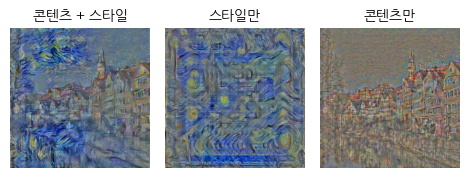

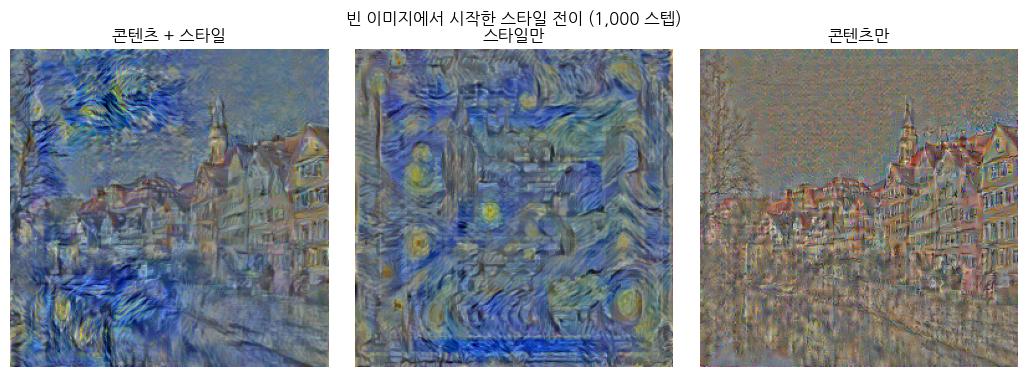

In [9]:

imgs = [denormalize(g)[0] for g in (gen_both, gen_style_only, gen_content_only)]
descs = ['콘텐츠 + 스타일', '스타일만', '콘텐츠만']
viz.plot_images(imgs, descs, images_per_row=3, fig_title_size=10)

# README에서 참조할 그림으로 저장
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.8))
for ax, img, desc in zip(axes, imgs, descs):
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(desc)
    ax.axis('off')
fig.suptitle('빈 이미지에서 시작한 스타일 전이 (1,000 스텝)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'style_transfer_01.png', dpi=200, bbox_inches='tight')
plt.show()

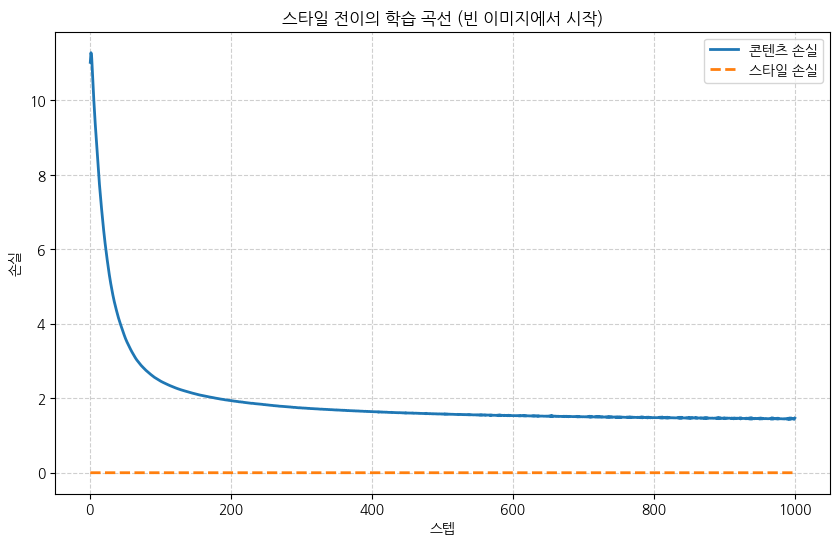

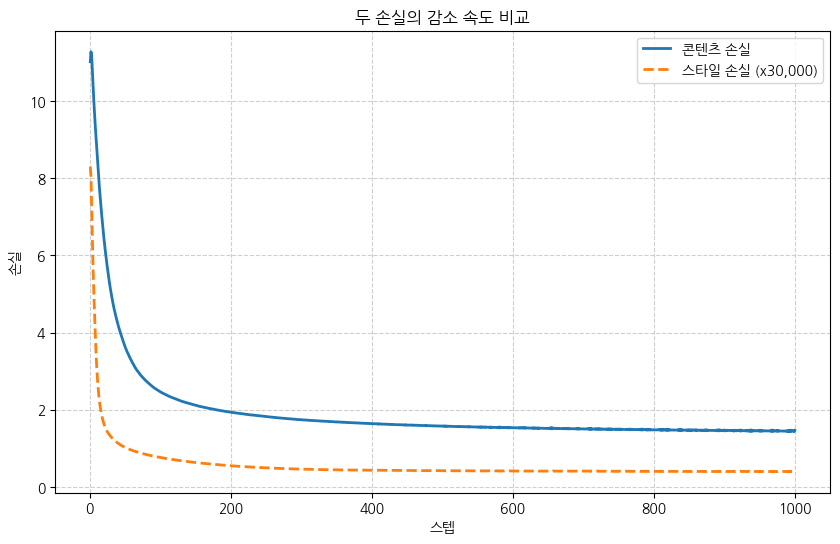

In [10]:

# 두 손실이 줄어드는 속도를 비교한다(스타일 쪽이 훨씬 빠르다)
log_both.plot(title='스타일 전이의 학습 곡선 (빈 이미지에서 시작)', x_label='스텝')

# 스타일 손실은 절댓값이 매우 작아 함께 보려면 스케일을 맞춰야 한다
scale = 30000
viz.plot_histories(
    {'콘텐츠 손실': log_both.history['콘텐츠 손실'],
     f'스타일 손실 (x{scale:,})': [v * scale for v in log_both.history['스타일 손실']]},
    title='두 손실의 감소 속도 비교', x_label='스텝', y_label='손실')

## 7. 콘텐츠 이미지에서 시작하기

백지 대신 콘텐츠 이미지에서 출발하면 문제의 성격이 바뀐다. "빈 화폭에 둘 다 그린다"에서
**"이미 있는 콘텐츠를 지키면서 스타일만 입힌다"**로 바뀐다.

콘텐츠 이미지에서 시작 (500 스텝)
 에포크  콘텐츠 손실  스타일 손실     시간
  1/500       0.0000     0.000151     0:00


 50/500       1.5967     0.000019     0:00


100/500       1.4521     0.000016     0:01


150/500       1.3959     0.000015     0:01


200/500       1.3689     0.000015     0:01


...

300/500       1.3279     0.000014     0:02


350/500       1.3184     0.000014     0:03


400/500       1.3076     0.000014     0:03


450/500       1.3029     0.000014     0:03


500/500       1.2982     0.000014     0:04
------------------------------------------
전체 학습 시간 0:04


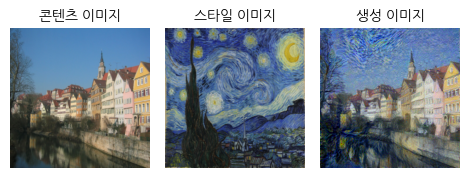

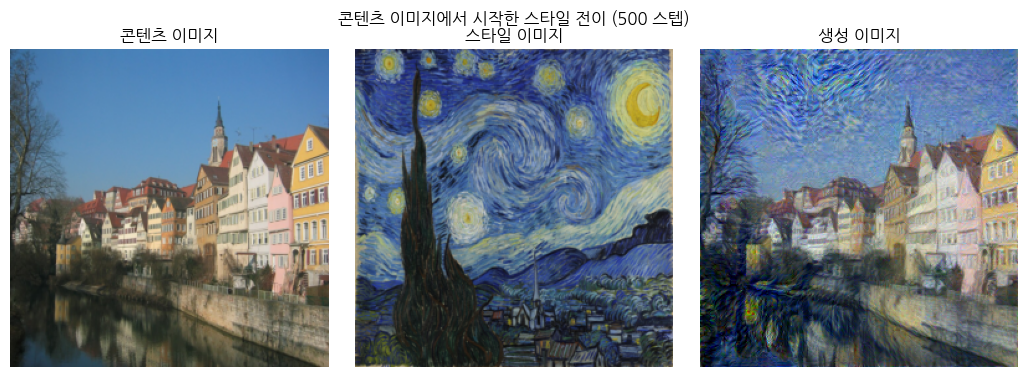

In [11]:

STEPS_CONTENT = 500
gen_from_content, log_from_content = run_style_transfer(
    content_img, content_img, style_img, feature_extractor,
    steps=STEPS_CONTENT, name='콘텐츠 이미지에서 시작 (500 스텝)')

imgs = [denormalize(content_img)[0], denormalize(style_img)[0],
        denormalize(gen_from_content)[0]]
descs = ['콘텐츠 이미지', '스타일 이미지', '생성 이미지']
viz.plot_images(imgs, descs, images_per_row=3, fig_title_size=10)

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.8))
for ax, img, desc in zip(axes, imgs, descs):
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(desc)
    ax.axis('off')
fig.suptitle('콘텐츠 이미지에서 시작한 스타일 전이 (500 스텝)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'style_transfer_02.png', dpi=200, bbox_inches='tight')
plt.show()

## 8. 가중치로 스타일 강도 조절하기

콘텐츠 가중치를 `1.0`으로 두고 스타일 가중치만 바꿔 본다.

style_weight = 1000
 에포크  콘텐츠 손실  스타일 손실     시간
  1/500       0.0000     0.000151     0:00


 50/500       0.0513     0.000111     0:00


100/500       0.0275     0.000102     0:01


150/500       0.0221     0.000097     0:01


200/500       0.0203     0.000094     0:01


...

300/500      11.1355     0.000001     0:02


350/500      11.0705     0.000001     0:03


400/500      10.9478     0.000001     0:03


450/500      10.8939     0.000001     0:03


500/500      10.8731     0.000001     0:04
------------------------------------------
전체 학습 시간 0:04



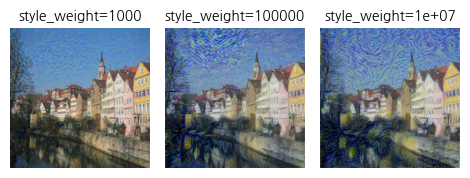

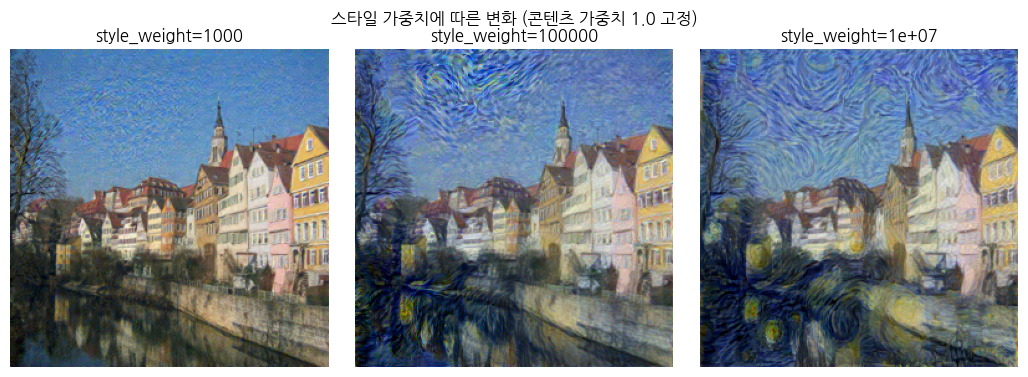

In [12]:

style_weights = [1e3, 1e5, 1e7]
gen_by_weight = {}
for sw in style_weights:
    gen_by_weight[sw], _ = run_style_transfer(
        content_img, content_img, style_img, feature_extractor,
        steps=STEPS_CONTENT, style_weight=sw, name=f'style_weight = {sw:g}')
    print()

imgs = [denormalize(gen_by_weight[sw])[0] for sw in style_weights]
descs = [f'style_weight={sw:g}' for sw in style_weights]
viz.plot_images(imgs, descs, images_per_row=3, fig_title_size=10)

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.8))
for ax, img, desc in zip(axes, imgs, descs):
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(desc)
    ax.axis('off')
fig.suptitle('스타일 가중치에 따른 변화 (콘텐츠 가중치 1.0 고정)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'style_transfer_03.png', dpi=200, bbox_inches='tight')
plt.show()

---

## 정리

| | 내용 |
|---|---|
| 최적화 대상 | 모델 파라미터가 아니어도 된다. 기울기가 흐르는 텐서면 무엇이든 가능하다 |
| 손실 함수 | 목적을 수식으로 옮길 수 있으면 직접 만들면 된다 |
| 사전 학습 모델 | 분류에만 쓰는 것이 아니다. 특징 추출기로 재활용할 수 있다 |
| 여러 손실항 | 합치기 전에 눈금이 맞는지 먼저 확인해야 한다 |
| 초기값 | 최적화 문제에서 **어디에서 출발하는가**가 결과와 속도를 크게 좌우한다 |

연습 문제는 [`README.md`](README.md)의 마지막 절에 있다. 이 노트북의 함수를
그대로 쓰면 대부분 인자만 바꿔 실험할 수 있다.
